In [1]:
# PRUNING: REDUCE THE OVER-FITTING OF DECISON TREE

In [2]:
# Loading the dataset

In [3]:
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer(as_frame=True)

X = breast_cancer.data
y = breast_cancer.target

In [4]:
df = breast_cancer.frame

In [5]:
print("\nHEAD")
display(df.head())

print("\nSHAPE")
display(df.shape)

print("\nCOLUMNS")
display(df.columns.tolist())

print("\nSTATISTICAL SUMMARY")
display(df.describe())


HEAD


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



SHAPE


(569, 31)


COLUMNS


['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']


STATISTICAL SUMMARY


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [6]:
import numpy as np

print("\nCATEGORICAL COLUMNS")
display(df.select_dtypes(include="object").columns.tolist())

print("\nNUMERICAL COLUMNS")
display(df.select_dtypes(include=np.number).columns.tolist())


CATEGORICAL COLUMNS


[]


NUMERICAL COLUMNS


['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

In [7]:
import pandas as pd

missing = df.isnull().sum()

missing_percentage = missing / len(df) * 100

missing_table = pd.DataFrame({
    "MISSING COUNT": missing,
    "MISSING PERCENTAGE": missing_percentage
})

display(missing_table)

,MISSING COUNT,MISSING PERCENTAGE
mean radius,0,0.0
mean texture,0,0.0
mean perimeter,0,0.0
mean area,0,0.0
mean smoothness,0,0.0
mean compactness,0,0.0
mean concavity,0,0.0
mean concave points,0,0.0
mean symmetry,0,0.0
mean fractal dimension,0,0.0


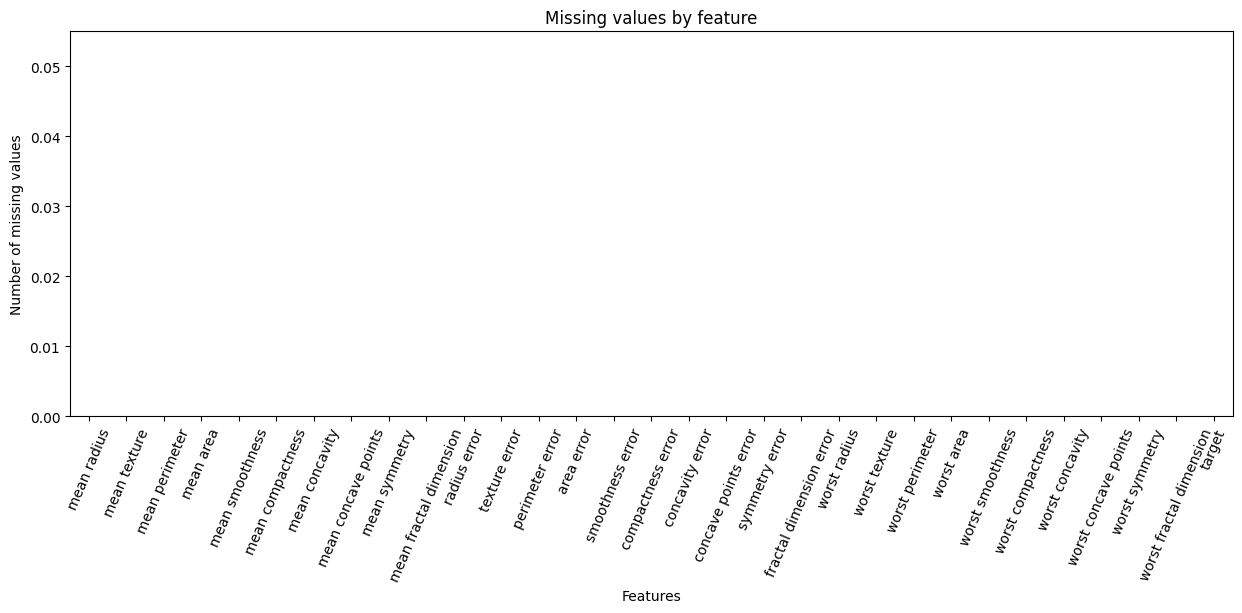

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
missing.plot(kind="bar")

plt.title("Missing values by feature")
plt.xlabel("Features")
plt.ylabel("Number of missing values")

plt.ylim(bottom=0)
plt.xticks(rotation=67)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.fit_transform(X_test)

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.tree import DecisionTreeClassifier

In [11]:
# UNPRUNED TREE

In [12]:
unpruned_tree = DecisionTreeClassifier()

unpruned_tree.fit(X_train_scaled, y_train)

unpruned_tree_pred_train = unpruned_tree.predict(X_train_scaled)
unpruned_tree_pred_test = unpruned_tree.predict(X_test_scaled)

In [13]:
print("\nUN-PRUNED TRAINING")
print("ACCURACY: ", accuracy_score(y_train, unpruned_tree_pred_train))
print("PRECISION: ", precision_score(y_train, unpruned_tree_pred_train, average='weighted'))
print("RECALL: ", recall_score(y_train, unpruned_tree_pred_train, average='weighted'))
print("F1 SCORE: ", f1_score(y_train, unpruned_tree_pred_train, average='weighted'))

print("\nUN-PRUNED TESTING")
print("ACCURACY: ", accuracy_score(y_test, unpruned_tree_pred_test))
print("PRECISION: ", precision_score(y_test, unpruned_tree_pred_test, average="weighted"))
print("RECALL: ", recall_score(y_test, unpruned_tree_pred_test, average="weighted"))
print("F1 SCORE: ", f1_score(y_test, unpruned_tree_pred_test, average="weighted"))


UN-PRUNED TRAINING
ACCURACY:  1.0
PRECISION:  1.0
RECALL:  1.0
F1 SCORE:  1.0

UN-PRUNED TESTING
ACCURACY:  0.8771929824561403
PRECISION:  0.8771929824561403
RECALL:  0.8771929824561403
F1 SCORE:  0.8771929824561403


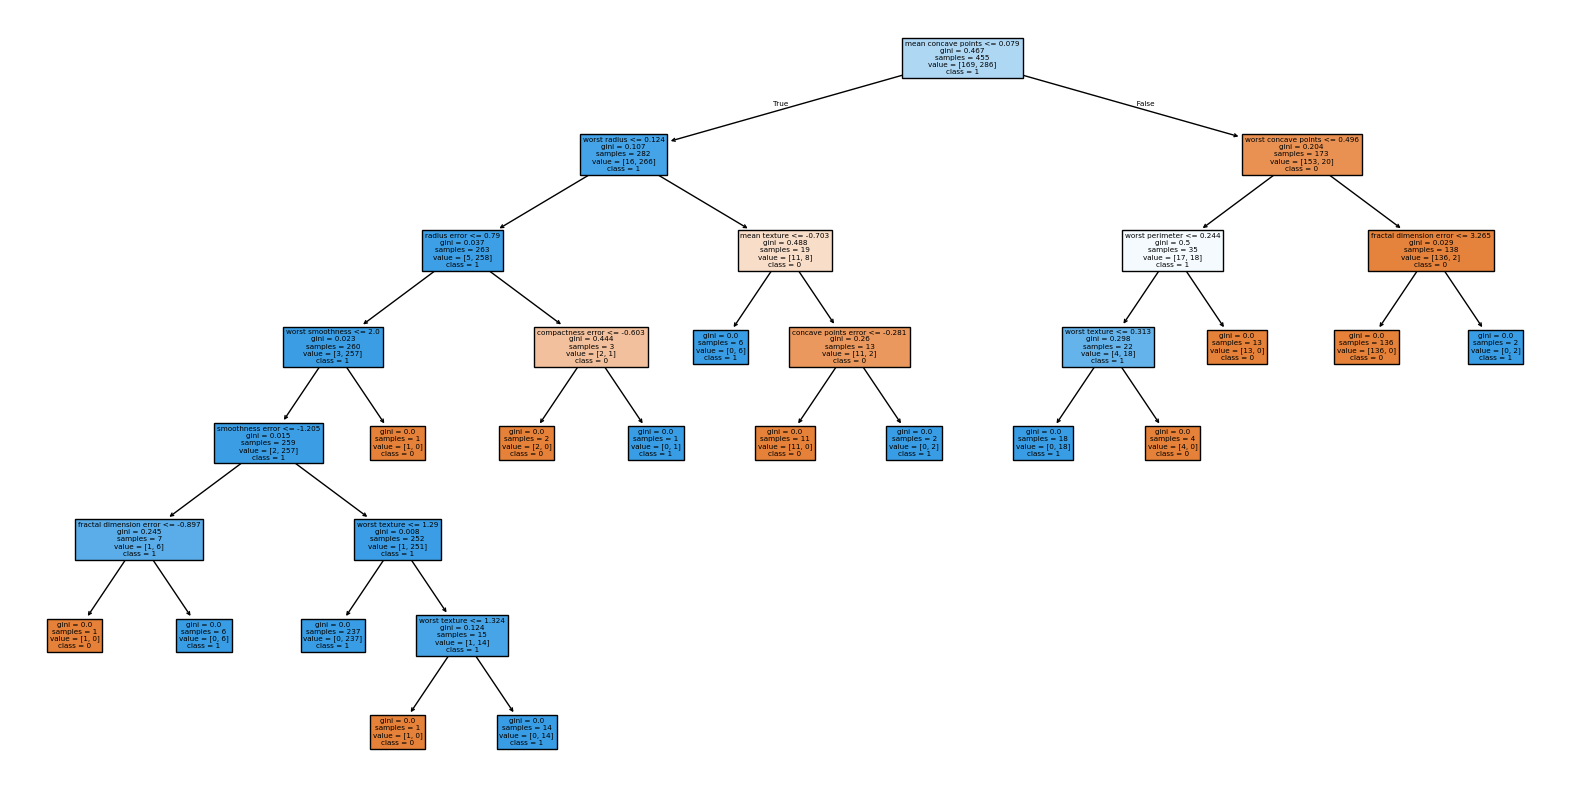

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    unpruned_tree,
    feature_names=X.columns,
    class_names=unpruned_tree.classes_.astype(str),
    filled=True
)

plt.show()

In [15]:
# PRE-PRUNING

In [16]:
prepruned_tree = DecisionTreeClassifier(
    max_depth=2
)

prepruned_tree.fit(X_train_scaled, y_train)

prepruned_tree_pred_train = prepruned_tree.predict(X_train_scaled)
prepruned_tree_pred_test = prepruned_tree.predict(X_test_scaled)

In [17]:
print("\nPRE-PRUNED TRAINING")
print("ACCURACY: ", accuracy_score(y_train, prepruned_tree_pred_train))
print("PRECISION: ", precision_score(y_train, prepruned_tree_pred_train, average='weighted'))
print("RECALL: ", recall_score(y_train, prepruned_tree_pred_train, average='weighted'))
print("F1 SCORE: ", f1_score(y_train, prepruned_tree_pred_train, average='weighted'))

print("\nPRE-PRUNED TESTING")
print("ACCURACY: ", accuracy_score(y_test, prepruned_tree_pred_test))
print("PRECISION: ", precision_score(y_test, prepruned_tree_pred_test, average="weighted"))
print("RECALL: ", recall_score(y_test, prepruned_tree_pred_test, average="weighted"))
print("F1 SCORE: ", f1_score(y_test, prepruned_tree_pred_test, average="weighted"))

print("\nDEPTH", prepruned_tree.get_depth())
print("\nLEAVES: ", prepruned_tree.get_n_leaves())


PRE-PRUNED TRAINING
ACCURACY:  0.9296703296703297
PRECISION:  0.9299375270990712
RECALL:  0.9296703296703297
F1 SCORE:  0.9290984836660944

PRE-PRUNED TESTING
ACCURACY:  0.9122807017543859
PRECISION:  0.9149039675355466
RECALL:  0.9122807017543859
F1 SCORE:  0.9107693219535326

DEPTH 2

LEAVES:  4


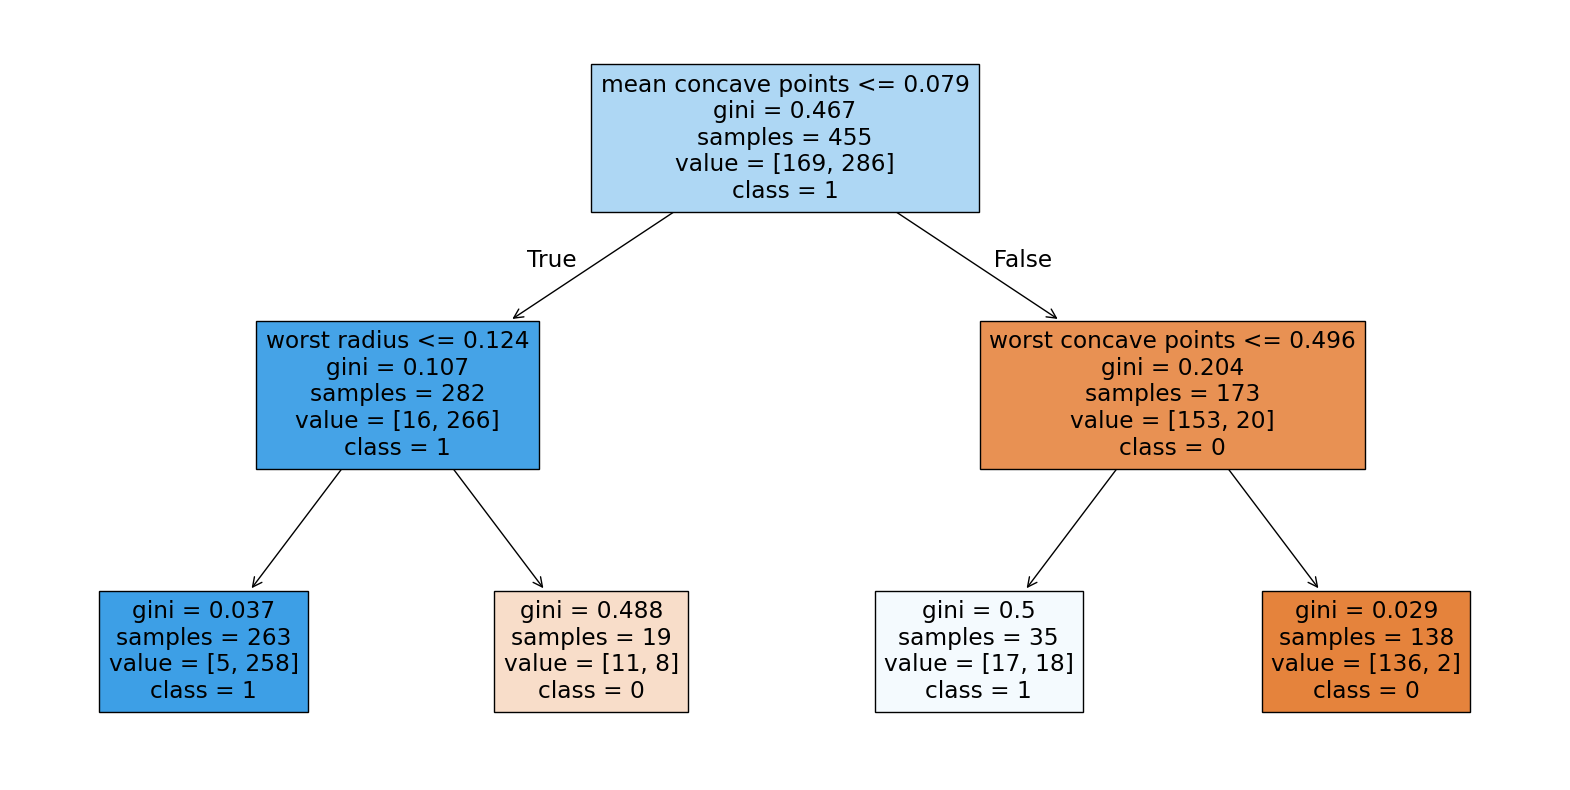

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    prepruned_tree,
    feature_names=X.columns,
    class_names=prepruned_tree.classes_.astype(str),
    filled=True
)

plt.show()

In [19]:
# POST-PRUNING

In [20]:
from sklearn.model_selection import train_test_split

X_train_prune, X_val, y_train_prune, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [21]:
full_tree = DecisionTreeClassifier(
    random_state=42
)

full_tree.fit(X_train_prune, y_train_prune)

DecisionTreeClassifier(random_state=42)

In [22]:
path = full_tree.cost_complexity_pruning_path(
    X_train_prune,
    y_train_prune
)

print("ALPHAS:", path.ccp_alphas)
print("IMPURITIES:", path.impurities)

ALPHAS: [0.         0.00270945 0.003663   0.00518926 0.00539895 0.00693129
 0.01551054 0.02470085 0.05332771 0.33027837]
IMPURITIES: [0.         0.01625668 0.01991968 0.02510894 0.03590684 0.04283813
 0.05834867 0.08304952 0.13637723 0.4666556 ]


In [23]:
results = []

for alpha in path.ccp_alphas:

    tree = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )

    tree.fit(X_train_prune, y_train_prune)

    train_pred = tree.predict(X_train_prune)
    val_pred = tree.predict(X_val)

    results.append({
        "ALPHA": alpha,
        "DEPTH": tree.get_depth(),
        "LEAVES": tree.get_n_leaves(),

        "TRAIN_ACCURACY": accuracy_score(
            y_train_prune,
            train_pred
        ),

        "VALIDATION_ACCURACY": accuracy_score(
            y_val,
            val_pred
        ),

        "TRAIN_PRECISION": precision_score(
            y_train_prune,
            train_pred,
            average="weighted"
        ),

        "VALIDATION_PRECISION": precision_score(
            y_val,
            val_pred,
            average="weighted"
        ),

        "TRAIN_RECALL": recall_score(
            y_train_prune,
            train_pred,
            average="weighted"
        ),

        "VALIDATION_RECALL": recall_score(
            y_val,
            val_pred,
            average="weighted"
        ),

        "TRAIN_F1": f1_score(
            y_train_prune,
            train_pred,
            average="weighted"
        ),

        "VALIDATION_F1": f1_score(
            y_val,
            val_pred,
            average="weighted"
        )
    })

results_df = pd.DataFrame(results)

display(results_df)

C:\Users\VarunKarmikanda\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\VarunKarmikanda\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,ALPHA,DEPTH,LEAVES,TRAIN_ACCURACY,VALIDATION_ACCURACY,TRAIN_PRECISION,VALIDATION_PRECISION,TRAIN_RECALL,VALIDATION_RECALL,TRAIN_F1,VALIDATION_F1
0,0.000000,7,16,1.000000,0.901099,1.000000,0.901884,1.000000,0.901099,1.000000,0.901378
1,0.002709,4,10,0.991758,0.923077,0.991865,0.922836,0.991758,0.923077,0.991739,0.922837
2,0.003663,4,9,0.989011,0.923077,0.989041,0.922836,0.989011,0.923077,0.988994,0.922837
3,0.005189,4,8,0.986264,0.923077,0.986259,0.922836,0.986264,0.923077,0.986253,0.922837
4,0.005399,3,6,0.980769,0.923077,0.980814,0.922836,0.980769,0.923077,0.980784,0.922837
5,0.006931,3,5,0.978022,0.934066,0.978017,0.934182,0.978022,0.934066,0.977988,0.933635
6,0.015511,3,4,0.969780,0.934066,0.969841,0.934182,0.969780,0.934066,0.969803,0.933635
7,0.024701,2,3,0.950549,0.912088,0.952050,0.912088,0.950549,0.912088,0.950821,0.912088
8,0.053328,1,2,0.925824,0.879121,0.928022,0.890150,0.925824,0.879121,0.924659,0.874324
9,0.330278,0,1,0.629121,0.626374,0.395793,0.392344,0.629121,0.626374,0.485898,0.482477


In [24]:
results.append({
    "ALPHA": alpha,
    "DEPTH": tree.get_depth(),
    "LEAVES": tree.get_n_leaves(),
    "TRAIN_ACCURACY": accuracy_score(y_train_prune, train_pred),
    "VALIDATION_ACCURACY": accuracy_score(y_val, val_pred)
})

In [25]:
best_row = results_df.loc[
    results_df["VALIDATION_ACCURACY"].idxmax()
]

display(best_row)

ALPHA                   0.006931
DEPTH                   3.000000
LEAVES                  5.000000
TRAIN_ACCURACY          0.978022
VALIDATION_ACCURACY     0.934066
TRAIN_PRECISION         0.978017
VALIDATION_PRECISION    0.934182
TRAIN_RECALL            0.978022
VALIDATION_RECALL       0.934066
TRAIN_F1                0.977988
VALIDATION_F1           0.933635
Name: 5, dtype: float64

In [26]:
best_alpha = best_row["ALPHA"]

In [27]:
final_tree = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    random_state=42
)

final_tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.006931294313501982),
                       random_state=42)

In [28]:
final_pred = final_tree.predict(X_test_scaled)

print("TEST ACCURACY:",
      accuracy_score(y_test, final_pred))

print("TEST PRECISION:",
      precision_score(
          y_test,
          final_pred,
          average="weighted"
      ))

print("TEST RECALL:",
      recall_score(
          y_test,
          final_pred,
          average="weighted"
      ))

print("TEST F1:",
      f1_score(
          y_test,
          final_pred,
          average="weighted"
      ))

TEST ACCURACY: 0.9298245614035088
TEST PRECISION: 0.9308322087269456
TEST RECALL: 0.9298245614035088
TEST F1: 0.9290742727182139


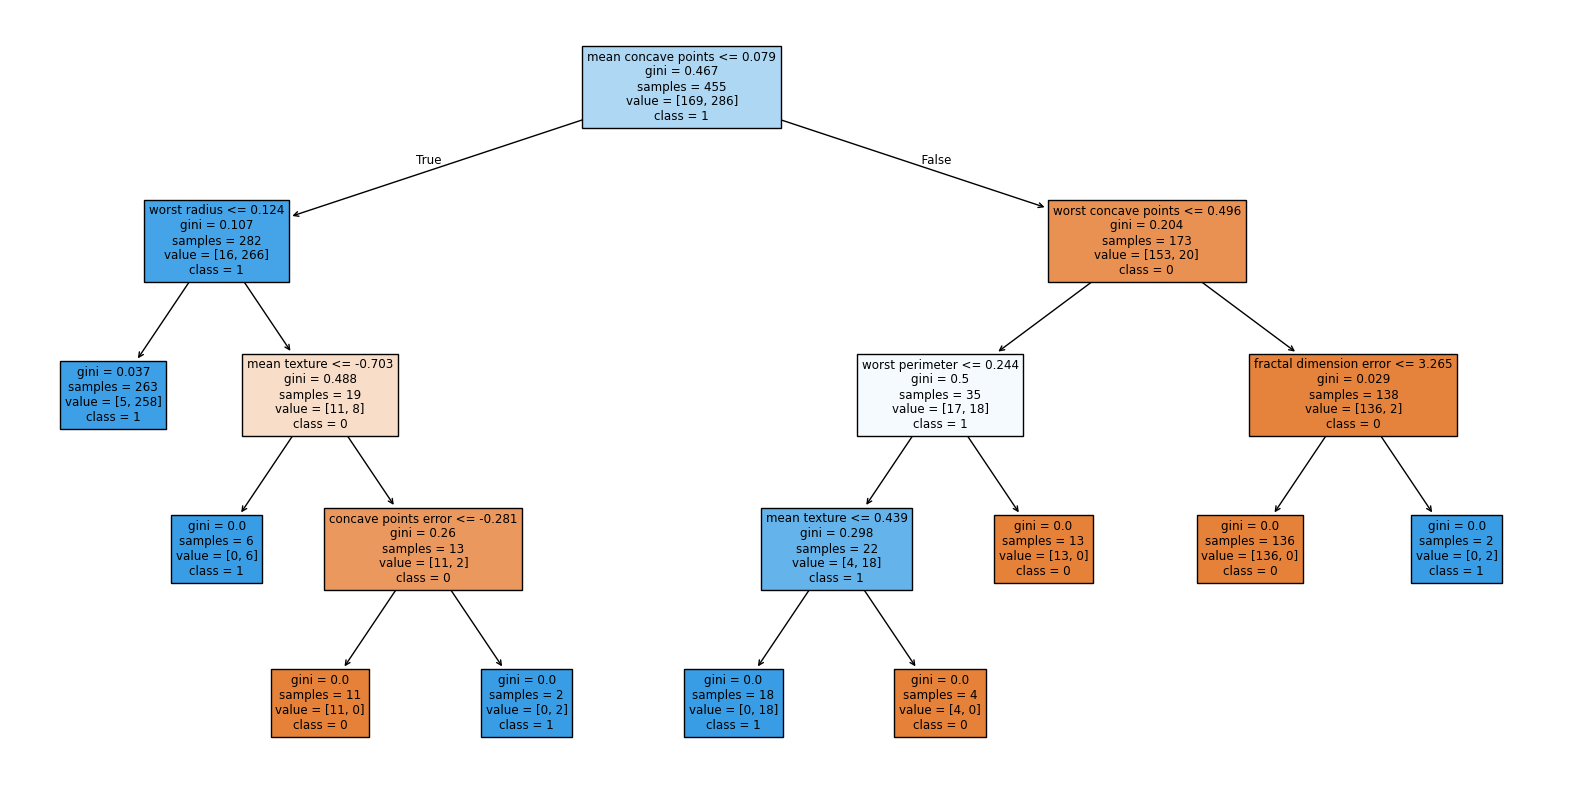

In [29]:
plt.figure(figsize=(20, 10))

plot_tree(
    final_tree,
    feature_names=X.columns,
    class_names=final_tree.classes_.astype(str),
    filled=True
)

plt.show()